# 02 — Skills Demand

Which technical skills appear most in German IT job postings. Examines the most frequently required skills, how they cluster by job family, co-occurrence patterns between skills, and distinctions between required and nice-to-have competencies.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 19,148 rows × 29 columns
After excluding future-dated rows: 19,098 rows


In [2]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, heatmap
from analysis.filters import explode_json_col
from analysis.compute import skill_counts, skill_cooccurrence

## Skill Coverage Statistics

In [3]:
from analysis.utils import parse_json_col

skills_parsed = parse_json_col(df, "technical_skills")
skill_lengths = skills_parsed.apply(len)

n_zero = (skill_lengths == 0).sum()
pct_zero = n_zero / len(df) * 100
avg_skills = skill_lengths.mean()
median_skills = skill_lengths.median()
max_skills = skill_lengths.max()

print(f"Total postings: {len(df):,}")
print(f"Postings with 0 skills extracted: {n_zero:,} ({pct_zero:.1f}%)")
print(f"Average skills per posting: {avg_skills:.1f}")
print(f"Median skills per posting: {median_skills:.0f}")
print(f"Max skills in a single posting: {max_skills}")

Total postings: 19,098
Postings with 0 skills extracted: 345 (1.8%)
Average skills per posting: 11.7
Median skills per posting: 11
Max skills in a single posting: 52


**Takeaway:** The vast majority of postings have at least one extracted skill, confirming that the LLM extraction pipeline captured skill information effectively. The average posting lists several technologies, reflecting the multi-skill nature of modern IT roles.

## Top 20 Technical Skills

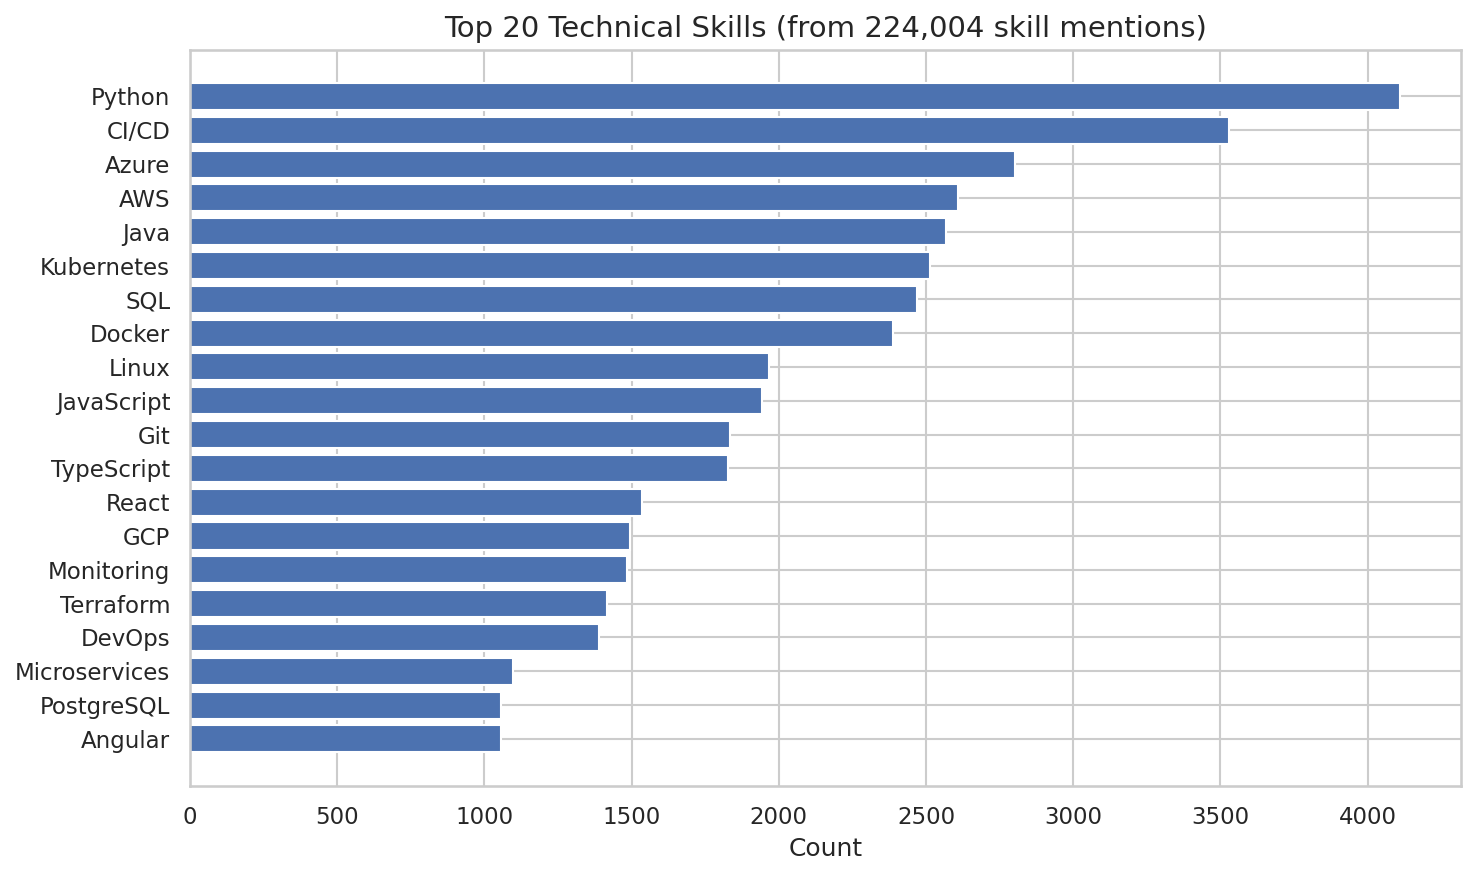

In [4]:
skills_exploded = explode_json_col(df, "technical_skills")
n_mentions = len(skills_exploded)
horizontal_bar(
    skills_exploded["technical_skills"],
    f"Top 20 Technical Skills (from {n_mentions:,} skill mentions)",
    top_n=20,
    save_as="02_top_skills.png",
)

**Takeaway:** A handful of foundational technologies dominate the market. Python, SQL, and JavaScript consistently appear at the top, reflecting their versatility across job families. Cloud platforms (AWS, Azure) and containerisation tools (Docker, Kubernetes) also feature prominently, underscoring the industry shift toward cloud-native development.

## Skills by Job Family (Heatmap)

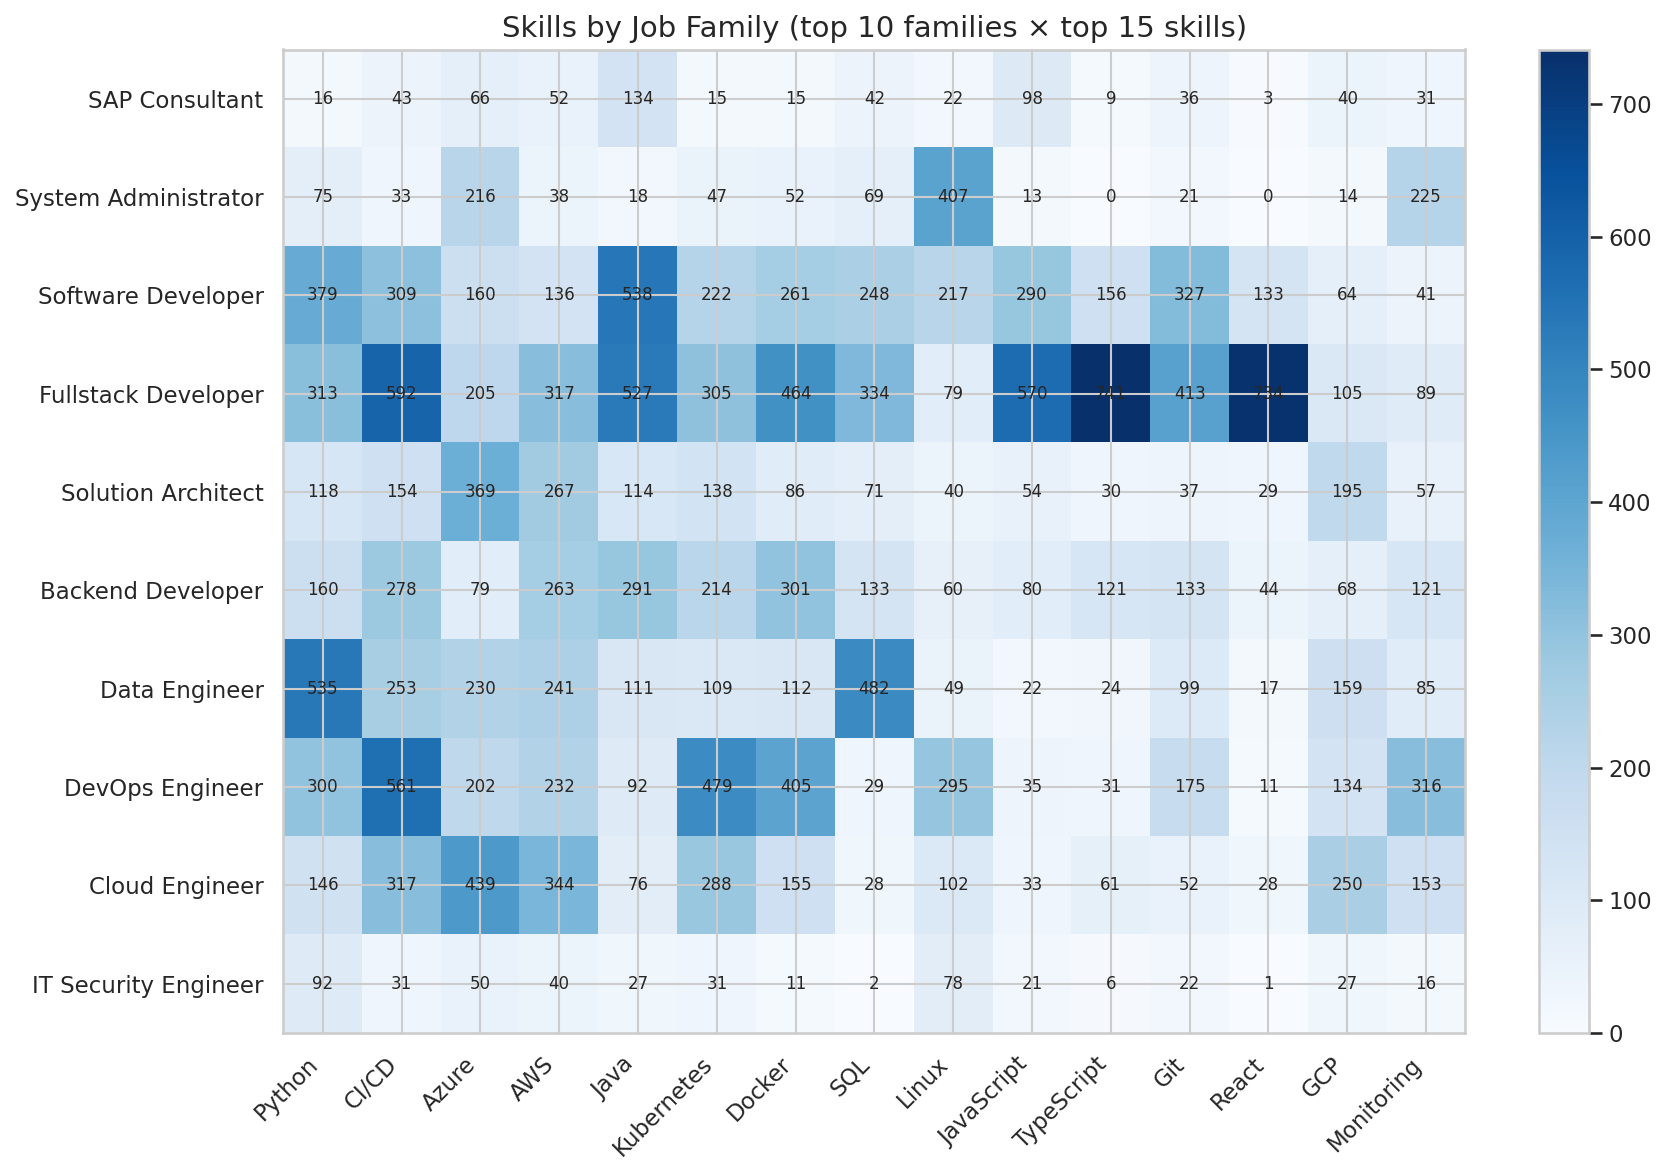

In [5]:
import pandas as pd

df_fam = exclude_other_family(df)
top_families = df_fam["job_family"].value_counts().head(10).index.tolist()

skills_fam = explode_json_col(df_fam, "technical_skills")
top_skills = skills_fam["technical_skills"].value_counts().head(15).index.tolist()

skill_family_df = skills_fam[
    skills_fam["job_family"].isin(top_families)
    & skills_fam["technical_skills"].isin(top_skills)
]
pivot = (
    skill_family_df.groupby(["job_family", "technical_skills"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(index=top_families, columns=top_skills, fill_value=0)
heatmap(pivot, f"Skills by Job Family (top 10 families × top 15 skills)", save_as="02_skill_family.png")

**Takeaway:** Skill requirements diverge sharply across job families. Data roles cluster around Python and SQL, while frontend roles concentrate on JavaScript/TypeScript and React. DevOps and infrastructure roles show strong Docker and Kubernetes demand. This heatmap reveals the distinct technical identity of each family.

## Co-occurrence Matrix

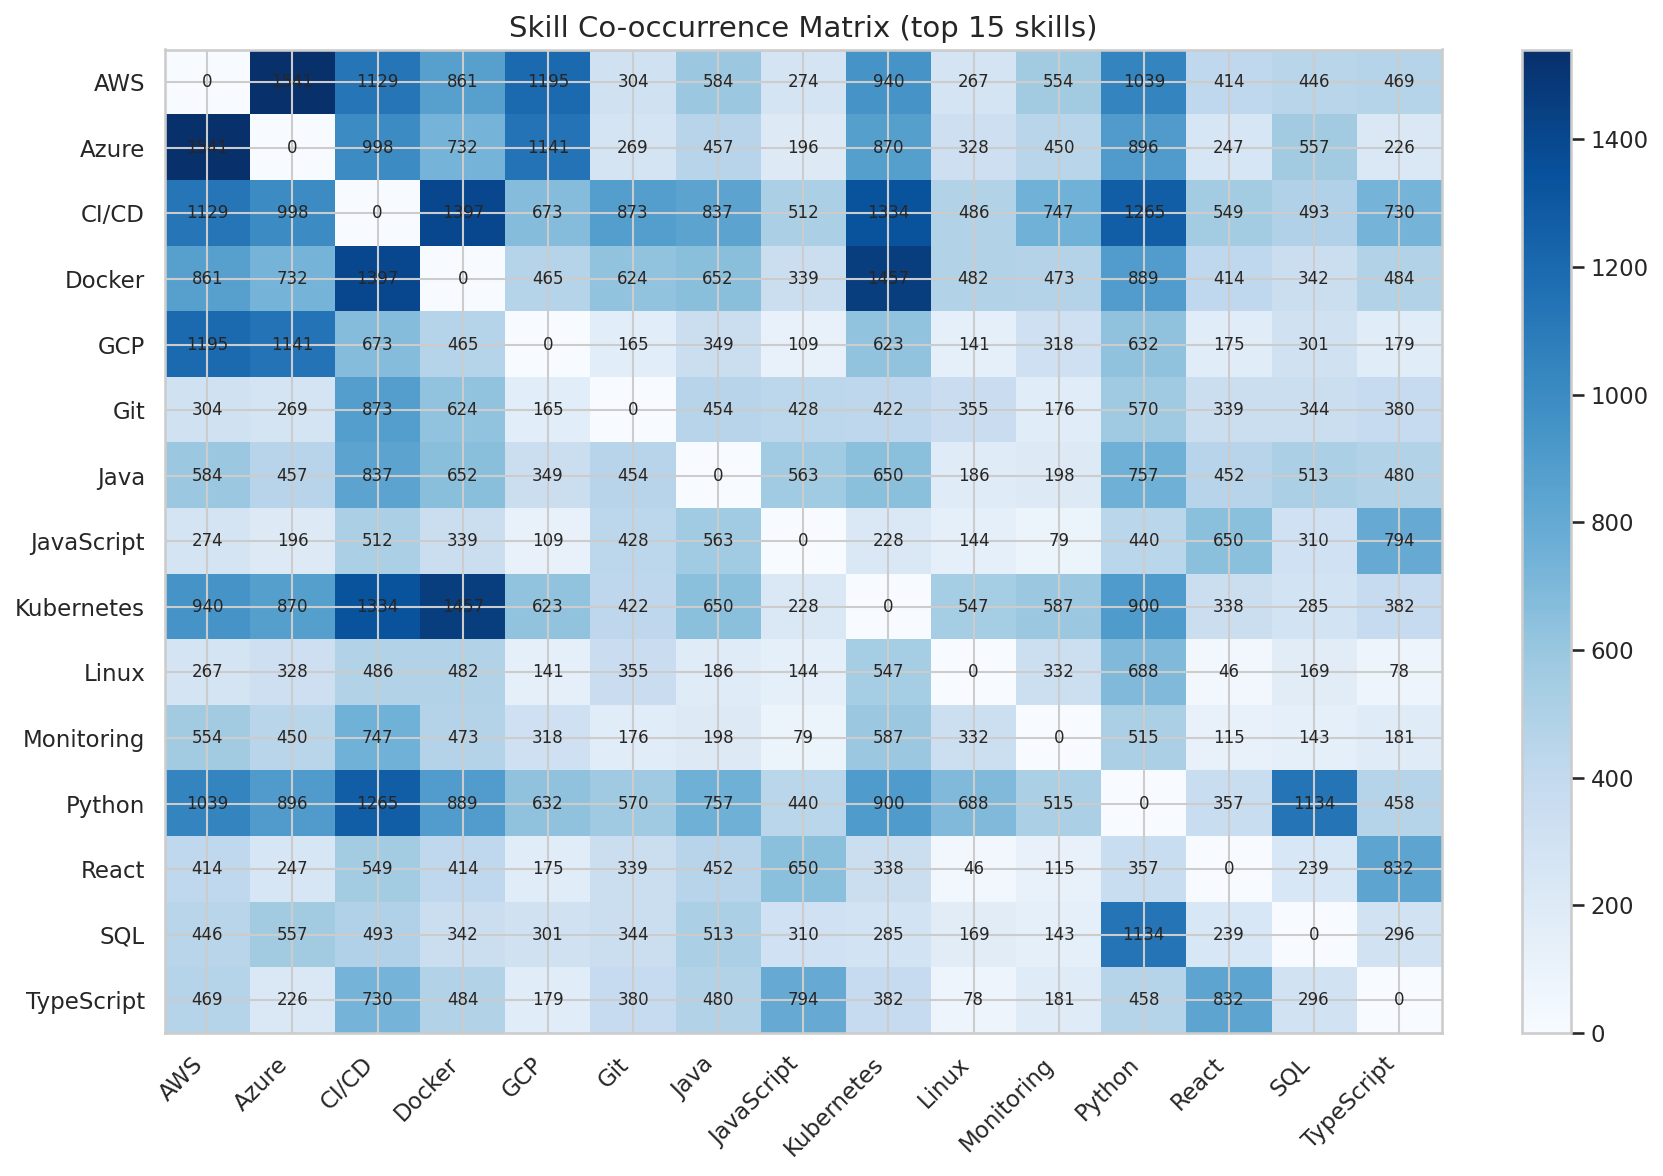

In [6]:
co_matrix = skill_cooccurrence(df, top_n=15)
heatmap(
    co_matrix,
    "Skill Co-occurrence Matrix (top 15 skills)",
    save_as="02_cooccurrence.png",
)

**Takeaway:** Strong co-occurrence clusters emerge around technology stacks. Python and SQL frequently appear together (data stack), as do JavaScript, TypeScript, and React (frontend stack). Docker and Kubernetes pair tightly in DevOps contexts. These clusters help identify the implicit "skill bundles" employers expect.